# Importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
import mysql.connector

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="NewPassword123!",
    database="eda_sql"
)

print("MySqQL Connected Sucessfully!")

MySqQL Connected Sucessfully!


In [4]:
query = "SELECT * FROM data"

df = pd.read_sql(query, conn)

df.head()

,SaleID,OrderDate,DeliveryDate,ProductCategory,Region,SalesAmount,UnitsSold,IsHoliday,PaymentMethod,TotalSales
0,1,2024-10-16,2024-10-19,Clothing,Bengaluru,141958,26,No,Credit Card,3690908.0
1,2,2023-04-25,2023-05-04,Clothing,Delhi,166867,32,No,Credit Card,5339744.0
2,3,2023-01-26,2023-01-28,Clothing,Bengaluru,151932,6,Yes,Credit Card,911592.0
3,4,2025-01-29,2025-02-03,Electronics,Hyderabad,123694,32,No,Credit Card,3958208.0
4,5,2023-10-09,2023-10-18,Furniture,Mumbai,139879,4,No,UPI,559516.0


Check shape 

In [6]:
df.shape

(200, 10)

check info

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SaleID           200 non-null    int64  
 1   OrderDate        200 non-null    str    
 2   DeliveryDate     200 non-null    str    
 3   ProductCategory  200 non-null    str    
 4   Region           200 non-null    str    
 5   SalesAmount      200 non-null    int64  
 6   UnitsSold        200 non-null    int64  
 7   IsHoliday        200 non-null    str    
 8   PaymentMethod    200 non-null    str    
 9   TotalSales       200 non-null    float64
dtypes: float64(1), int64(3), str(6)
memory usage: 24.6 KB


Statistical Analysis for numerical data 

In [8]:
df.describe()

,SaleID,SalesAmount,UnitsSold,TotalSales
count,200.000000,200.000000,200.000000,2.000000e+02
mean,100.500000,109566.395000,25.905000,2.827478e+06
std,57.879185,51369.852864,13.686584,2.155629e+06
min,1.000000,20769.000000,1.000000,5.935300e+04
25%,50.750000,67481.750000,16.000000,1.019130e+06
50%,100.500000,113025.500000,26.000000,2.398238e+06
75%,150.250000,148610.000000,35.250000,4.159576e+06
max,200.000000,199997.000000,49.000000,9.315504e+06


Statistical Analysis for Categorical Data 

In [9]:
df.describe(include='object')

,OrderDate,DeliveryDate,ProductCategory,Region,IsHoliday,PaymentMethod
count,200,200,200,200,200,200
unique,173,187,4,7,2,4
top,2024-03-08,2024-10-19,Electronics,Hyderabad,No,Credit Card
freq,3,2,56,36,164,60


Checking the Data Types

In [10]:
df.dtypes

SaleID               int64
OrderDate              str
DeliveryDate           str
ProductCategory        str
Region                 str
SalesAmount          int64
UnitsSold            int64
IsHoliday              str
PaymentMethod          str
TotalSales         float64
dtype: object

 Checking the top 5 rows

In [11]:
df.head()

,SaleID,OrderDate,DeliveryDate,ProductCategory,Region,SalesAmount,UnitsSold,IsHoliday,PaymentMethod,TotalSales
0,1,2024-10-16,2024-10-19,Clothing,Bengaluru,141958,26,No,Credit Card,3690908.0
1,2,2023-04-25,2023-05-04,Clothing,Delhi,166867,32,No,Credit Card,5339744.0
2,3,2023-01-26,2023-01-28,Clothing,Bengaluru,151932,6,Yes,Credit Card,911592.0
3,4,2025-01-29,2025-02-03,Electronics,Hyderabad,123694,32,No,Credit Card,3958208.0
4,5,2023-10-09,2023-10-18,Furniture,Mumbai,139879,4,No,UPI,559516.0


Checking the Bottom 5 rows

In [12]:
df.tail()

,SaleID,OrderDate,DeliveryDate,ProductCategory,Region,SalesAmount,UnitsSold,IsHoliday,PaymentMethod,TotalSales
195,196,2025-01-09,2025-01-12,Furniture,Delhi,189695,32,No,Cash,6070240.0
196,197,2025-01-06,2025-01-14,Clothing,Hyderabad,27392,23,No,Cash,630016.0
197,198,2023-09-27,2023-10-06,Electronics,Bengaluru,75680,22,No,Credit Card,1664960.0
198,199,2024-05-27,2024-06-01,Electronics,Kolkata,197789,25,No,Credit Card,4944725.0
199,200,2025-02-19,2025-03-01,Furniture,Pune,70859,22,No,Debit Card,1558898.0


Day_Name, Month_Name, Year columns add

In [16]:
import pandas as pd

# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Create date-related columns
df['Day_Name'] = df['OrderDate'].dt.day_name()
df['Month_Name'] = df['OrderDate'].dt.month_name()
df['Year'] = df['OrderDate'].dt.year

# Check result
df[['OrderDate', 'Day_Name', 'Month_Name', 'Year']].head()

,OrderDate,Day_Name,Month_Name,Year
0,2024-10-16,Wednesday,October,2024
1,2023-04-25,Tuesday,April,2023
2,2023-01-26,Thursday,January,2023
3,2025-01-29,Wednesday,January,2025
4,2023-10-09,Monday,October,2023


In [19]:
df.head()

,SaleID,OrderDate,DeliveryDate,ProductCategory,Region,SalesAmount,UnitsSold,IsHoliday,PaymentMethod,TotalSales,Day_Name,Month_Name,Year,Day
0,1,2024-10-16,2024-10-19,Clothing,Bengaluru,141958,26,No,Credit Card,3690908.0,Wednesday,October,2024,16
1,2,2023-04-25,2023-05-04,Clothing,Delhi,166867,32,No,Credit Card,5339744.0,Tuesday,April,2023,25
2,3,2023-01-26,2023-01-28,Clothing,Bengaluru,151932,6,Yes,Credit Card,911592.0,Thursday,January,2023,26
3,4,2025-01-29,2025-02-03,Electronics,Hyderabad,123694,32,No,Credit Card,3958208.0,Wednesday,January,2025,29
4,5,2023-10-09,2023-10-18,Furniture,Mumbai,139879,4,No,UPI,559516.0,Monday,October,2023,9


In [18]:
df['Day'] = df['OrderDate'].dt.day

Check the null values 

In [20]:
df.isnull().sum()

SaleID             0
OrderDate          0
DeliveryDate       0
ProductCategory    0
Region             0
SalesAmount        0
UnitsSold          0
IsHoliday          0
PaymentMethod      0
TotalSales         0
Day_Name           0
Month_Name         0
Year               0
Day                0
dtype: int64

# Analysis (by Visualization)

Univariate analysis

1. Region-wise total SalesAmount

In [22]:
sales_by_region = df.groupby('Region')['SalesAmount'].sum()

In [23]:
df.head(2)

,SaleID,OrderDate,DeliveryDate,ProductCategory,Region,SalesAmount,UnitsSold,IsHoliday,PaymentMethod,TotalSales,Day_Name,Month_Name,Year,Day
0,1,2024-10-16,2024-10-19,Clothing,Bengaluru,141958,26,No,Credit Card,3690908.0,Wednesday,October,2024,16
1,2,2023-04-25,2023-05-04,Clothing,Delhi,166867,32,No,Credit Card,5339744.0,Tuesday,April,2023,25


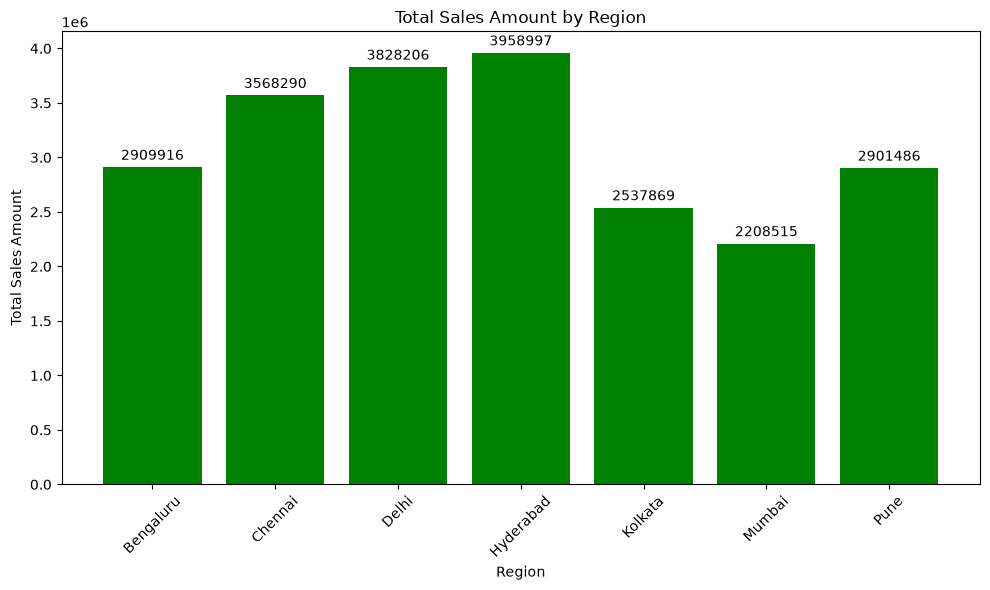

In [26]:
plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_region.index, sales_by_region.values, color='green')
plt.bar_label(bars, fmt='%.0f', padding=3)

plt.xlabel('Region')
plt.ylabel('Total Sales Amount')
plt.title('Total Sales Amount by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 5 location with the highest no of uitssold

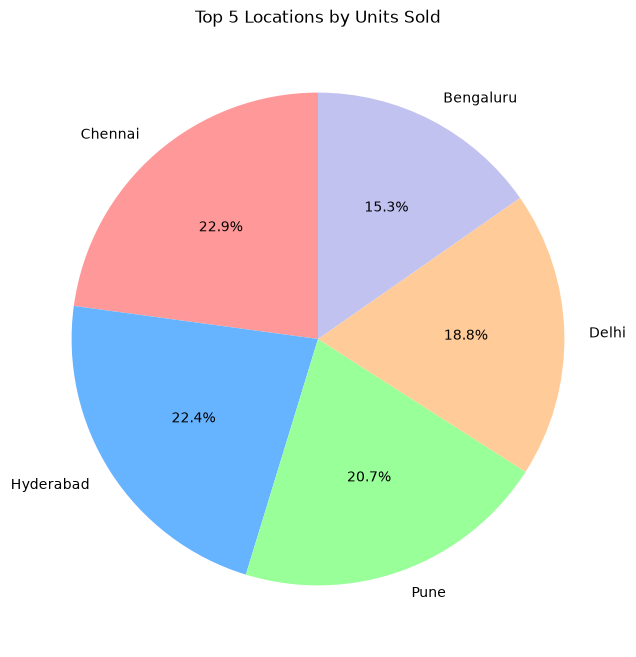

In [27]:
top_5 = df.groupby('Region')['UnitsSold'].sum().nlargest(5)


plt.figure(figsize=(8, 8))

plt.pie(
    top_5.values,
    labels=top_5.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
)

plt.title('Top 5 Locations by Units Sold')
plt.show()

Count the Number of unitssold by product category 

In [28]:
units_by_category = df.groupby('ProductCategory')['UnitsSold'].sum()

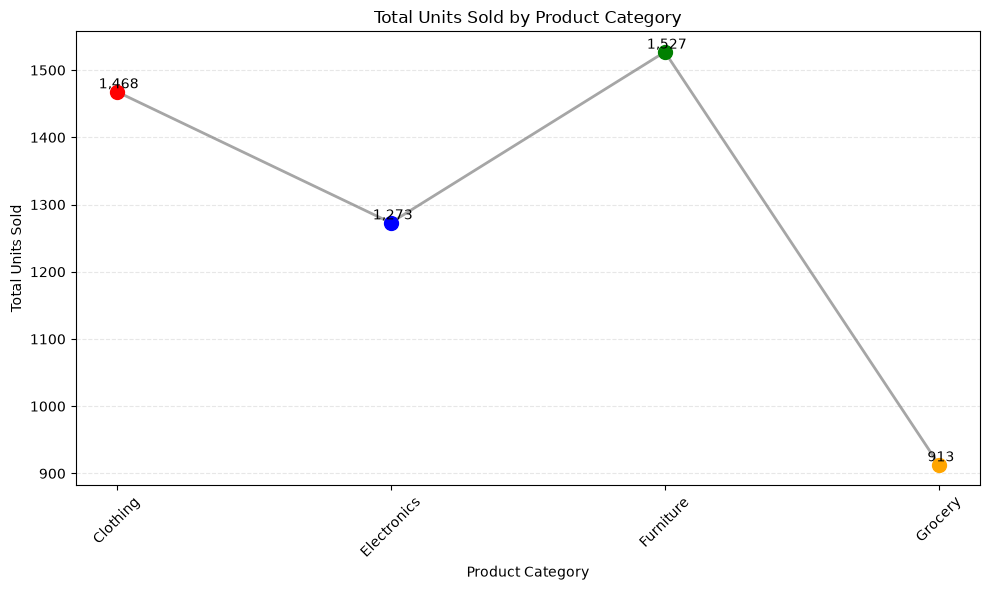

In [29]:
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

plt.figure(figsize=(10, 6))

plt.plot(
    units_by_category.index,
    units_by_category.values,
    color='gray',
    linewidth=2,
    alpha=0.7
)

# Different color markers + labels
for i, (category, value) in enumerate(units_by_category.items()):
    plt.scatter(
        category,
        value,
        color=colors[i % len(colors)],
        s=100,
        zorder=3
    )

    plt.text(
        category,
        value,
        f' {value:,}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Product Category')
plt.ylabel('Total Units Sold')
plt.title('Total Units Sold by Product Category')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The Number of Product Category By Year

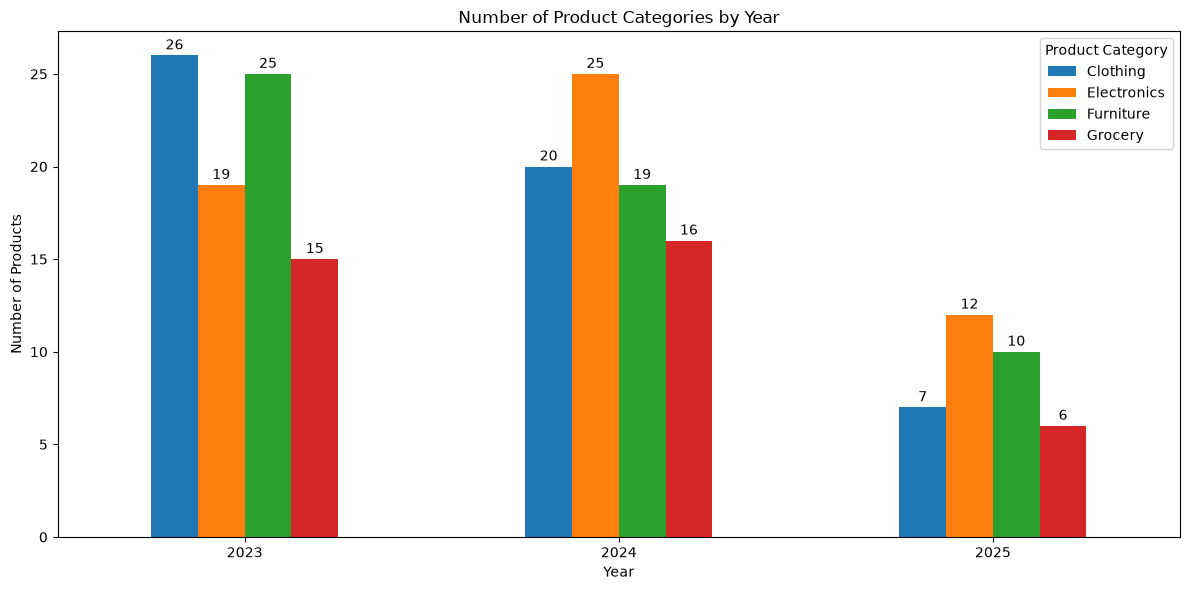

In [30]:
# Count number of products/categories by year
category_by_year = df.groupby(
    ['Year', 'ProductCategory']
).size().unstack(fill_value=0)

# Plot
ax = category_by_year.plot(
    kind='bar',
    figsize=(12, 6)
)

# Bar labels
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.xlabel('Year')
plt.ylabel('Number of Products')
plt.title('Number of Product Categories by Year')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()